In [170]:
!pip install pot

In [171]:
# ===========================
# 📌 Import Required Libraries
# ===========================
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine, euclidean, mahalanobis
from scipy.stats import entropy, wasserstein_distance, ks_2samp
from scipy.linalg import pinv
from sklearn.metrics.pairwise import rbf_kernel
import ot
import matplotlib.pyplot as plt
import argparse
from tqdm import tqdm  # Import tqdm for progress bar
import importlib
import matplotlib.pyplot as plt
from metrics import * # Ensure all functions are available
importlib.reload(metrics)  # Reload metrics.py to ensure the latest version is used
#from metrics import compute_maximum_mean_discrepancy  # Now, try importing again
#from metrics import compute_bhattacharyya  # Now, try importing again
#from metrics import compute_kolmogorov_smirnov  # Now, try importing again

# make sure metrics.py is in the same folder
from metrics import (
    compute_cosine_similarity,
    compute_euclidean_similarity,
    compute_mahalanobis_similarity,
    compute_kullback_leibler,
    compute_jensen_shannon,
    compute_earth_movers,
    compute_maximum_mean_discrepancy,
    compute_bhattacharyya,
    compute_entropy,
    compute_kolmogorov_smirnov,
    compute_optimal_transport,
    compute_share_of_drifted_components,
    convert_to_probability_distribution,
)



In [172]:
# ===========================
# User Input for File Names
# ===========================
def get_user_input():
    """Prompt user for input filenames and selected metrics."""
    in_dist_file = input("Enter the filename for in-distribution features: ")
    out_dist_file = input("Enter the filename for out-of-distribution features (Press Enter if not available): ")

    print("\nAvailable Metrics:")
    metric_names = [
        "Cosine Similarity", "Euclidean Distance", "Mahalanobis Distance",
        "Kullback-Leibler Divergence", "Jensen-Shannon Divergence",
        "Earth Mover’s Distance",
        "Maximum Mean Discrepancy", "Bhattacharyya Distance",
        "Entropy", "Kolmogorov-Smirnov Test",
        "Optimal Transport Distance",
        "Share of Drifted Components"
    ]

    for i, name in enumerate(metric_names, 1):
        print(f"{i}. {name}")

    selected_indices = input("Select metric numbers (comma-separated) or type 'all' for all metrics: ")
    if selected_indices.lower() == 'all':
        selected_metrics = metric_names
    else:
        selected_indices = [int(i) for i in selected_indices.split(',')]
        selected_metrics = [metric_names[i - 1] for i in selected_indices]

    visualize = input("Do you want to visualize the results? (yes/no): ").strip().lower() == 'yes'
    return in_dist_file, out_dist_file, selected_metrics, visualize

# ===========================
# Load Features from CSV
# ===========================
def load_features(file_path):
    """Load feature vectors from a CSV file."""
    return pd.read_csv(file_path, header=None).values


In [173]:
def compute_metrics(in_features, out_features, selected_metrics, pbar):
    metrics_map = {
        "Cosine Similarity": compute_cosine_similarity,
        "Euclidean Distance": compute_euclidean_similarity,
        "Mahalanobis Distance": compute_mahalanobis_similarity,
        "Kullback-Leibler Divergence": compute_kullback_leibler,
        "Jensen-Shannon Divergence": compute_jensen_shannon,
        "Earth Mover’s Distance": compute_earth_movers,
        "Maximum Mean Discrepancy": compute_maximum_mean_discrepancy,
        "Bhattacharyya Distance": compute_bhattacharyya,
        "Entropy": compute_entropy,
        "Kolmogorov-Smirnov Test": compute_kolmogorov_smirnov,
        "Optimal Transport Distance": compute_optimal_transport,
        "Share of Drifted Components": compute_share_of_drifted_components,
    }

    in_dist_results = {}
    ood_results = {}

    # Precompute cost matrix for Optimal Transport if selected
    cost_matrix = None
    if "Optimal Transport Distance" in selected_metrics:
        centroid = np.mean(in_features, axis=0)
        cost_matrix = np.abs(np.subtract.outer(centroid, centroid))  # Cost matrix for OT

    for metric_name in selected_metrics:
        func = metrics_map[metric_name]

        if metric_name == "Entropy":  # Special case: compute_entropy only takes one argument
            in_dist_results[metric_name] = func(in_features)
        elif metric_name == "Optimal Transport Distance":  # Special case: compute_optimal_transport takes three arguments
            in_dist_results[metric_name] = func(
                convert_to_probability_distribution(np.mean(in_features, axis=0)),
                convert_to_probability_distribution(np.mean(in_features, axis=0)),
                cost_matrix,
            )
        elif metric_name == "Share of Drifted Components":  # Special case for drift detection
            in_dist_results[metric_name] = func(in_features, in_features)
        else:
            in_dist_results[metric_name] = func(in_features, in_features)

        if out_features is not None:
            if metric_name == "Entropy":  # Special case for entropy
                ood_results[metric_name] = func(out_features)
            elif metric_name == "Optimal Transport Distance":  # Special case for OT
                ood_results[metric_name] = func(
                    convert_to_probability_distribution(np.mean(in_features, axis=0)),
                    convert_to_probability_distribution(np.mean(out_features, axis=0)),
                    cost_matrix,
                )
            elif metric_name == "Share of Drifted Components":  # Special case for drift detection
                ood_results[metric_name] = func(in_features, out_features)
            else:
                ood_results[metric_name] = func(in_features, out_features)

        pbar.update(1)

    return in_dist_results, ood_results


In [174]:
def save_results(in_dist_results, ood_results):
    """
    Saves computed metrics to CSV files, ensuring proper formatting and comprehensive statistics.

    Args:
        in_dist_results (dict): Dictionary of computed in-distribution metric results.
        ood_results (dict): Dictionary of computed out-of-distribution metric results (if available).

    Returns:
        None
    """
    # Compute comprehensive statistics for in-distribution results
    in_dist_stats = {}
    for metric, values in in_dist_results.items():
        # Ensure `values` is a list
        if not isinstance(values, (list, np.ndarray)):
            values = [values]

        # Calculate various statistics
        in_dist_stats[metric] = {
            "mean": np.mean(values),
            "std": np.std(values),
            "min": np.min(values),
            "max": np.max(values),
            "median": np.median(values),
            "q1": np.percentile(values, 25),  # First quartile
            "q3": np.percentile(values, 75),  # Third quartile
            "range": np.max(values) - np.min(values),
        }

    # Convert statistics to a DataFrame
    in_dist_stats_df = pd.DataFrame.from_dict(in_dist_stats, orient="index")
    in_dist_stats_df.to_csv("In_Distribution_Stats.csv", index=True)

    # Format and save OOD results directly (if available)
    if ood_results:
        ood_formatted = {}
        for metric, values in ood_results.items():
            # Ensure `values` is a list
            if not isinstance(values, (list, np.ndarray)):
                values = [values]
            ood_formatted[metric] = values

        # Convert to DataFrame and save
        ood_df = pd.DataFrame.from_dict(ood_formatted, orient="index").T  # Transpose to match expected format
        ood_df.to_csv("OOD_Sample_Metrics.csv", index=False)

    print("✅ Results saved successfully!")

In [175]:
def visualize_metrics(in_dist_results, ood_results):
    """
    Visualize metrics as histograms.
    """
    metrics = list(in_dist_results.keys())
    num_metrics = len(metrics)

    plt.figure(figsize=(15, 5 * ((num_metrics + 2) // 3)))  # Adjust figure size dynamically

    for i, metric_name in enumerate(metrics, 1):
        plt.subplot((num_metrics + 2) // 3, 3, i)
        plt.hist(
            in_dist_results[metric_name],
            bins=50,
            color="#ADD8E6",
            alpha=0.7,
            label="In-Dist",
        )
        if ood_results:
            plt.hist(
                ood_results[metric_name],
                bins=50,
                color="red",
                alpha=0.3,
                label="OOD",
            )
        plt.title(f"{metric_name} Distribution")
        plt.xlabel(metric_name)
        plt.ylabel("Frequency")
        plt.legend()

    plt.tight_layout()
    plt.show()


Enter the filename for in-distribution features: in_dist_features.csv
Enter the filename for out-of-distribution features (Press Enter if not available): out_dist_features.csv

Available Metrics:
1. Cosine Similarity
2. Euclidean Distance
3. Mahalanobis Distance
4. Kullback-Leibler Divergence
5. Jensen-Shannon Divergence
6. Earth Mover’s Distance
7. Maximum Mean Discrepancy
8. Bhattacharyya Distance
9. Entropy
10. Kolmogorov-Smirnov Test
11. Optimal Transport Distance
12. Share of Drifted Components
Select metric numbers (comma-separated) or type 'all' for all metrics: all
Do you want to visualize the results? (yes/no): yes
📥 Loading feature data...
⚙️ Computing selected metrics...


Progress: 100%|██████████| 12/12 [02:48<00:00, 14.03s/metric]


💾 Saving results...
✅ Results saved successfully!
📊 Generating visualizations...


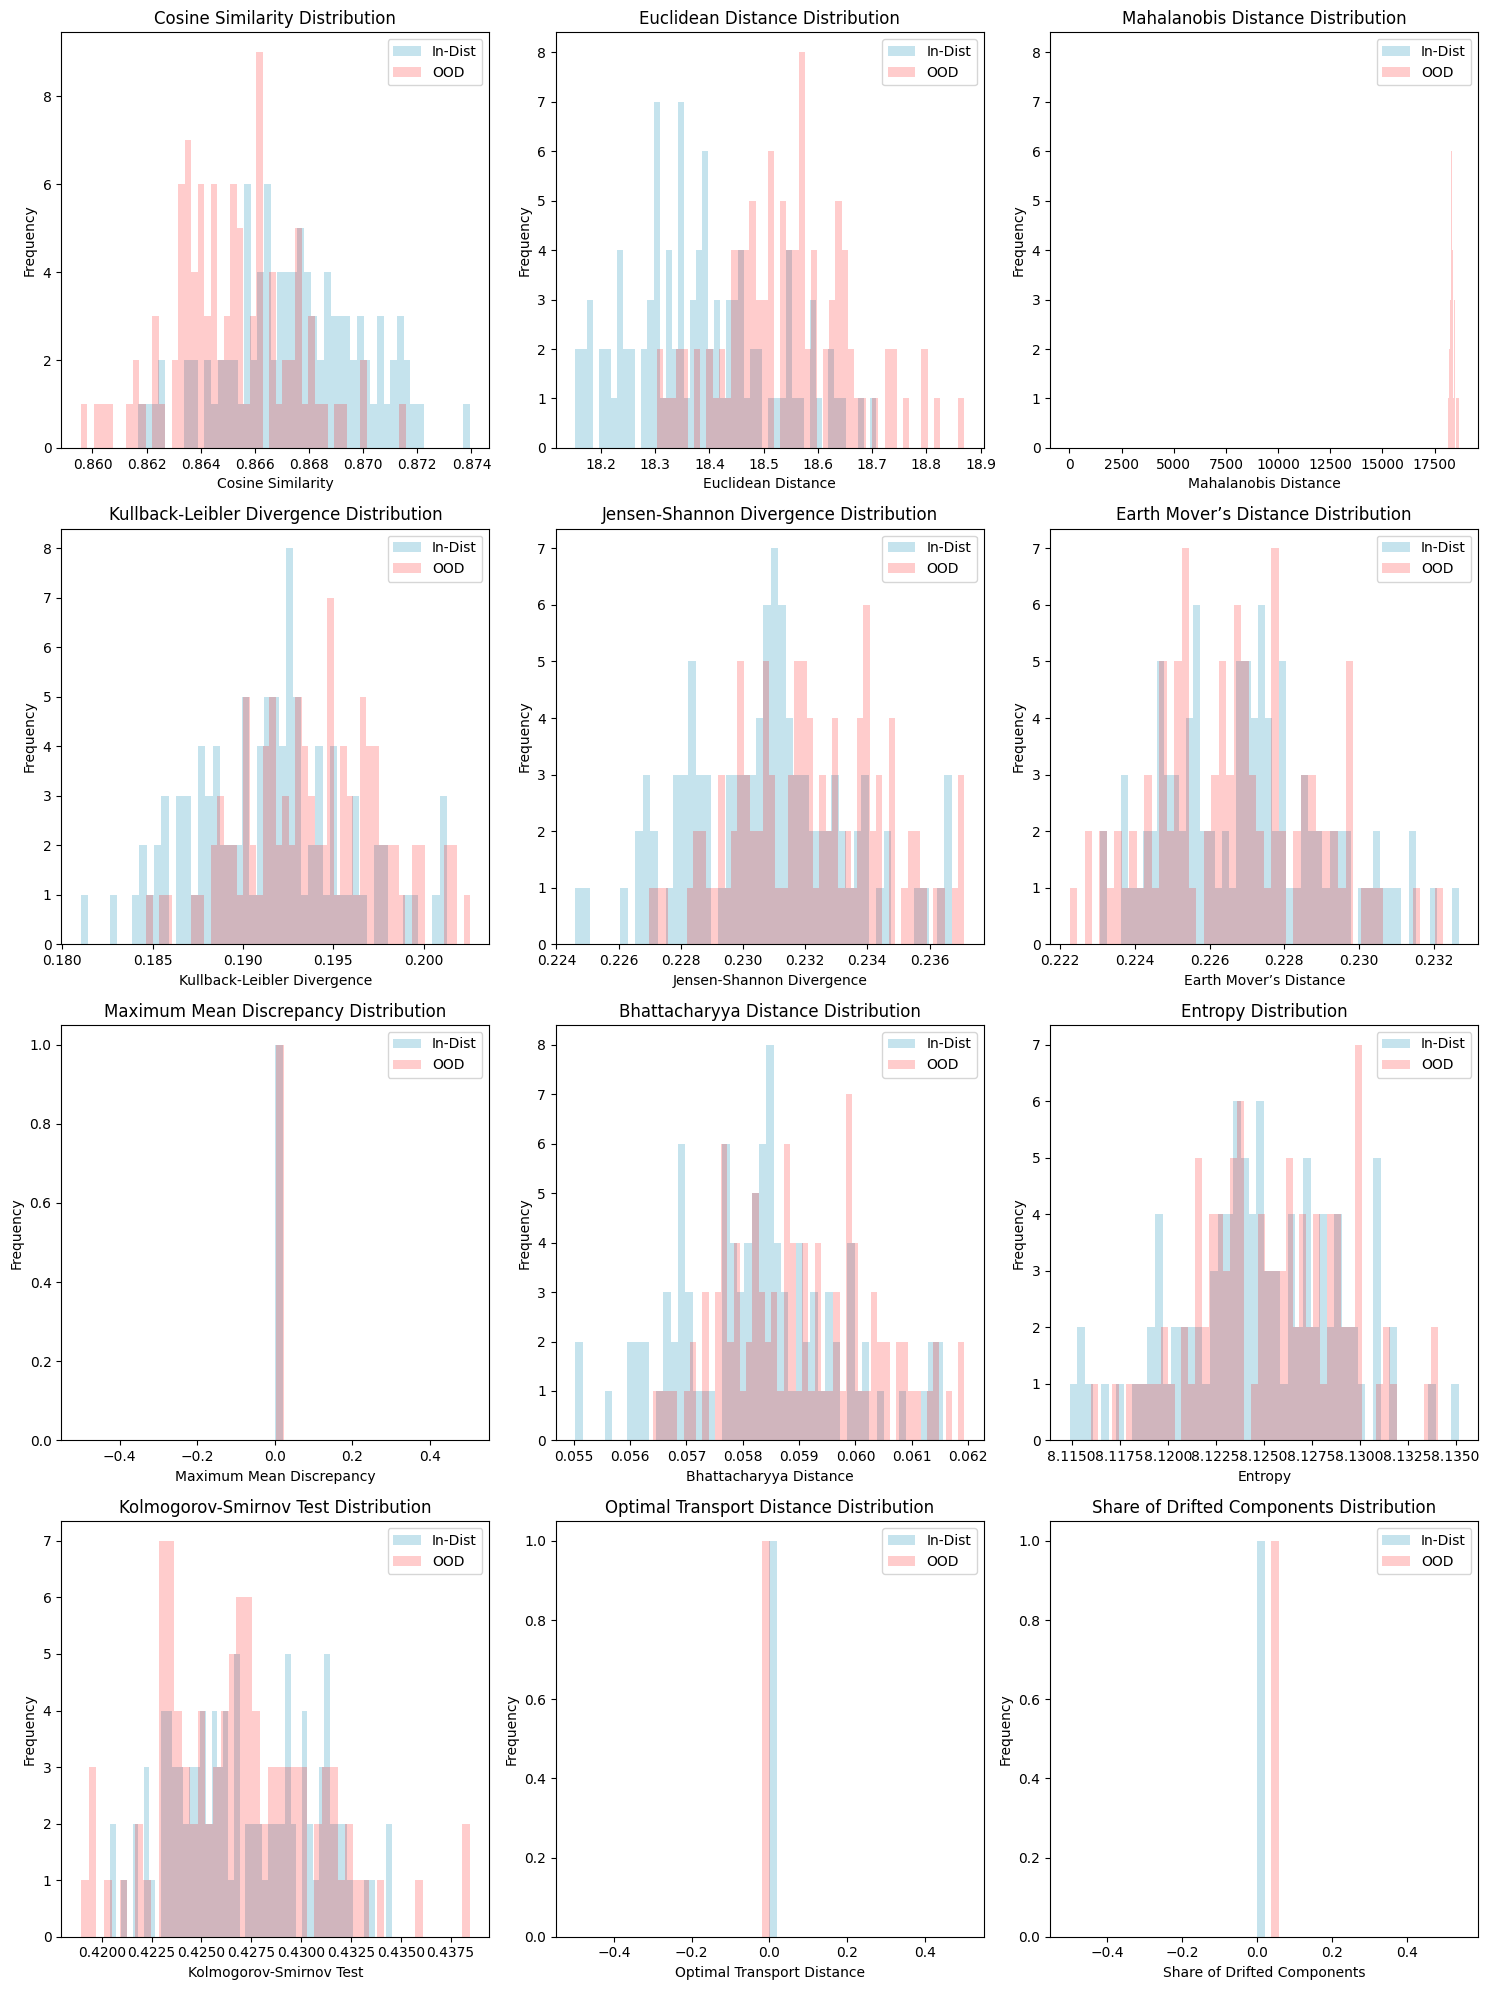

✅ Process completed successfully!


In [176]:
if __name__ == "__main__":
    in_dist_file, out_dist_file, selected_metrics, visualize = get_user_input()

    # Load in-distribution features
    print("📥 Loading feature data...")
    in_features = load_features(in_dist_file)
    out_features = load_features(out_dist_file) if out_dist_file else None

    # Compute selected metrics with progress bar
    print("⚙️ Computing selected metrics...")
    with tqdm(total=len(selected_metrics), desc="Progress", unit="metric") as pbar:
        in_dist_results, ood_results = compute_metrics(in_features, out_features, selected_metrics, pbar)

    # Save results
    print("💾 Saving results...")
    save_results(in_dist_results, ood_results)

    # Visualization (if selected by user)
    if visualize:
        print("📊 Generating visualizations...")
        visualize_metrics(in_dist_results, ood_results)

    print("✅ Process completed successfully!")


In [184]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Replace these imports with actual metric implementations
from metrics import (
    compute_cosine_similarity,
    compute_euclidean_similarity,
    compute_mahalanobis_similarity,
    compute_kullback_leibler,
    compute_jensen_shannon,
    compute_earth_movers,
    compute_maximum_mean_discrepancy,
    compute_bhattacharyya,
    compute_entropy,
    compute_kolmogorov_smirnov,
    compute_optimal_transport,
    compute_share_of_drifted_components,
    convert_to_probability_distribution,
)

# ===========================
# Generate Synthetic Data
# ===========================
np.random.seed(42)  # For reproducibility
in_features = np.random.rand(100, 10)  # 100 samples, 10 features
out_features = np.random.rand(80, 10)  # 80 samples, 10 features

# ===========================
# Helper Functions
# ===========================

def validate_features(features):
    """
    Validates that the feature matrix does not contain NaNs or infinities.

    Args:
        features (np.ndarray): Input feature matrix.

    Raises:
        ValueError: If NaNs or infinities are found in the matrix.
    """
    if not np.all(np.isfinite(features)):
        raise ValueError("Feature matrix contains NaNs or infinities.")

def normalize_features(features):
    """
    Normalizes feature vectors using StandardScaler.

    Args:
        features (np.ndarray): Input feature matrix.

    Returns:
        np.ndarray: Normalized feature matrix.
    """
    scaler = StandardScaler()
    return scaler.fit_transform(features)

# ===========================
# Define Metric Computation
# ===========================
def compute_metrics(in_features, out_features, selected_metrics):
    """
    Computes the selected metrics for in-distribution and out-of-distribution features.

    Args:
        in_features (np.ndarray): In-distribution feature vectors.
        out_features (np.ndarray): Out-of-distribution feature vectors (if available).
        selected_metrics (list): List of selected metrics to compute.

    Returns:
        dict: Computed metrics for in-distribution features.
        dict: Computed metrics for out-of-distribution features (if available).
    """
    metrics_map = {
        "Cosine Similarity": compute_cosine_similarity,
        "Euclidean Distance": compute_euclidean_similarity,
        "Mahalanobis Distance": compute_mahalanobis_similarity,
        "Kullback-Leibler Divergence": compute_kullback_leibler,
        "Jensen-Shannon Divergence": compute_jensen_shannon,
        "Earth Mover’s Distance": compute_earth_movers,
        "Maximum Mean Discrepancy": compute_maximum_mean_discrepancy,
        "Bhattacharyya Distance": compute_bhattacharyya,
        "Entropy": compute_entropy,
        "Kolmogorov-Smirnov Test": compute_kolmogorov_smirnov,
        "Optimal Transport Distance": compute_optimal_transport,
        "Share of Drifted Components": compute_share_of_drifted_components,
    }

    in_dist_results = {}
    ood_results = {}

    # Precompute cost matrix for Optimal Transport
    cost_matrix = None
    if "Optimal Transport Distance" in selected_metrics:
        centroid = np.mean(in_features, axis=0)
        cost_matrix = np.abs(np.subtract.outer(centroid, centroid))  # Cost matrix for OT

    for metric_name in selected_metrics:
        try:
            func = metrics_map[metric_name]

            if metric_name == "Entropy":  # Special case for entropy
                in_dist_results[metric_name] = func(in_features)
            elif metric_name == "Optimal Transport Distance":  # Special case for OT
                in_dist_results[metric_name] = func(
                    convert_to_probability_distribution(np.mean(in_features, axis=0)),
                    convert_to_probability_distribution(np.mean(in_features, axis=0)),
                    cost_matrix,
                )
            else:
                in_dist_results[metric_name] = func(in_features, in_features)

            if out_features is not None:
                if metric_name == "Entropy":
                    ood_results[metric_name] = func(out_features)
                elif metric_name == "Optimal Transport Distance":
                    ood_results[metric_name] = func(
                        convert_to_probability_distribution(np.mean(in_features, axis=0)),
                        convert_to_probability_distribution(np.mean(out_features, axis=0)),
                        cost_matrix,
                    )
                elif metric_name == "Share of Drifted Components":
                    ood_results[metric_name] = func(in_features, out_features)
                else:
                    ood_results[metric_name] = func(in_features, out_features)
        except Exception as e:
            print(f"Error computing {metric_name}: {e}")

    return in_dist_results, ood_results

# ===========================
# Save Results to CSV
# ===========================
def save_results(in_dist_results, ood_results):
    """
    Saves computed metrics to CSV files, handling both scalar and list metrics.

    Args:
        in_dist_results (dict): Dictionary of computed in-distribution metric results.
        ood_results (dict): Dictionary of computed out-of-distribution metric results (if available).

    Returns:
        None
    """
    # Compute summary stats for in-distribution metrics
    in_dist_stats = {}
    for metric, values in in_dist_results.items():
        if isinstance(values, list):  # Per-sample metrics
            in_dist_stats[metric] = {
                "mean": np.mean(values),
                "std": np.std(values),
                "min": np.min(values),
                "max": np.max(values),
                "median": np.median(values),
                "q1": np.percentile(values, 25),
                "q3": np.percentile(values, 75),
                "range": np.max(values) - np.min(values),
            }
        else:  # Scalar metrics
            in_dist_stats[metric] = {
                "mean": values,
                "std": 0,
                "min": values,
                "max": values,
                "median": values,
                "q1": values,
                "q3": values,
                "range": 0,
            }

    # Save in-distribution statistics to CSV
    in_dist_df = pd.DataFrame(in_dist_stats).T
    in_dist_df.to_csv("In_Distribution_Stats.csv", index=True)

    # Save OOD metrics to CSV
    if ood_results:
        ood_formatted = {
            metric: value if isinstance(value, list) else [value]
            for metric, value in ood_results.items()
        }
        ood_df = pd.DataFrame.from_dict(ood_formatted, orient="index").T
        ood_df.to_csv("OOD_Sample_Metrics.csv", index=False)

    print("✅ Results saved successfully!")

# ===========================
# Main Execution
# ===========================
if __name__ == "__main__":
    # Validate and normalize features
    validate_features(in_features)
    validate_features(out_features)

    in_features_normalized = normalize_features(in_features)
    out_features_normalized = normalize_features(out_features)

    # Compute metrics
    selected_metrics = [
        "Cosine Similarity",
        "Euclidean Distance",
        "Mahalanobis Distance",
        "Kullback-Leibler Divergence",
        "Jensen-Shannon Divergence",
        "Earth Mover’s Distance",
        "Maximum Mean Discrepancy",
        "Bhattacharyya Distance",
        "Entropy",
        "Kolmogorov-Smirnov Test",
        "Optimal Transport Distance",
        "Share of Drifted Components",
    ]

    print("⚙️ Computing selected metrics...")
    with tqdm(total=len(selected_metrics), desc="Progress", unit="metric") as pbar:
        in_dist_results, ood_results = compute_metrics(
            in_features_normalized, out_features_normalized, selected_metrics
        )
        pbar.update(len(selected_metrics))

    # Save results
    print("💾 Saving results...")
    save_results(in_dist_results, ood_results)

    print("✅ Process completed successfully!")

print(in_dist_results)

⚙️ Computing selected metrics...


Progress:   0%|          | 0/12 [00:00<?, ?metric/s]/content/metrics.py:287: RuntimeWarning: invalid value encountered in sqrt
  -np.log(np.sum(np.sqrt((sample / np.sum(sample)) * centroid_prob)) + 1e-10)
Progress: 100%|██████████| 12/12 [00:00<00:00, 37.72metric/s]

💾 Saving results...
✅ Results saved successfully!
✅ Process completed successfully!
{'Cosine Similarity': [0.5111865849076525, 0.02288904231044231, -0.09179494963598511, -0.25235140660769306, 0.30424063265143286, -0.5907822588759699, 0.18800476630016627, -0.4815804167051252, 0.19277638714903644, -0.5510846189804504, -0.057177363865184905, -0.13885517249622636, -0.03337507242292381, 0.14741770143558042, -0.31035528688106195, -0.058847416898093696, -0.38716921956441763, -0.10763451266930923, 0.033835125686632495, 0.5551729134831319, -0.047962687912026514, 0.22231352034077767, 0.214027442502553, -0.4817815272509798, 0.3883968369508737, 0.07095530372069203, -0.19085431140940612, 0.1151344068562905, -0.1889913816221731, -0.1236756888793975, -0.12401744375586721, -0.36781915463016523, -0.4612492744930352, 0.20337189132351874, -0.46770513502480027, 0.32525207331564565, -0.13969066651577755, 0.0750359477024537, -0.05956929679824374, 0.043353489396758205, -0.16128775003473517, -0.13088732350932